In [1]:
import pandas as pd 
from pathlib import Path
import re 
import json 
import matplotlib.pyplot as plt

In [2]:
p = Path("/home/finn/workspace/creatures/logs/simulation_1782563299.log")
assert p.exists()

In [15]:
with open(p, "r") as f:
    lines = f.readlines()

print(len(lines))

17315


In [16]:
def extract_animal_data(line):
    m = re.match(
        r".*animal_despawn,reason=(?P<reason>.*),spawn_at_frame=(?P<spawn_at>.*),despawn_at_frame=(?P<despawn_at>.*),lifetime_frames=(?P<lifetime>.*),genome=(?P<genome>.*),diet=(?P<diet>.*),family=(?P<family>.*).*",
        line,
    )

    if m is not None:
        d = {}
        d["reason"] = m.group("reason")
        d["spawn_at"] = float(m.group("spawn_at"))
        d["despawn_at"] = float(m.group("despawn_at"))
        d["lifetime"] = float(m.group("lifetime"))
        d["genome"] = m.group("genome")
        d["diet"] = m.group("diet")
        d["family"] = int(m.group("family"))
        return d
    return None


In [17]:
df = pd.DataFrame(list(filter(None, map(extract_animal_data, lines))))
df

,reason,spawn_at,despawn_at,lifetime,genome,diet,family
0,starvation,3.0,302.0,299.0,"[-0.09095931, 0.27592206, 0.568655, 0.56266594...",Carnivore,3652179443
1,starvation,317.0,1227.0,910.0,"[-0.4915266, 0.6011691, -0.7362821, 0.09686971...",Omnivore,1893112597
2,starvation,0.0,1334.0,1334.0,"[-0.38813543, 0.8613992, 0.76623106, 0.3038671...",Omnivore,0
3,starvation,974.0,1451.0,477.0,"[-0.71127844, 0.19468808, -0.20717192, -0.6587...",Carnivore,4026671404
4,starvation,1787.0,2008.0,221.0,"[-0.77485394, -0.7612109, -0.14076996, -0.8585...",Carnivore,3397224529
...,...,...,...,...,...,...,...
3106,shutdown,45928.0,46632.0,704.0,"[0.41020456, -0.5134429, -0.9049513, 0.7792696...",Herbivore,2459958712
3107,shutdown,45356.0,46632.0,1276.0,"[0.44072416, -0.5208172, -0.9377446, 0.784847,...",Herbivore,2459958712
3108,shutdown,46440.0,46632.0,192.0,"[0.38035196, -0.51995134, -0.82311267, 0.73738...",Herbivore,2459958712
3109,shutdown,46380.0,46632.0,252.0,"[0.18218969, 0.41356698, 0.7658133, 0.88359433...",Carnivore,1841908271


In [18]:
df.sort_values("lifetime")

,reason,spawn_at,despawn_at,lifetime,genome,diet,family
2115,collision,27762.0,27766.0,4.0,"[-0.22957659, 0.85381246, 0.6894007, -0.203036...",Omnivore,2778177171
2043,collision,27631.0,27636.0,5.0,"[-0.35226747, -0.33742285, 0.10016127, -0.3529...",Herbivore,1076406509
966,collision,11017.0,11022.0,5.0,"[-0.1905557, 0.66536945, -0.45841402, -0.99960...",Herbivore,4237578481
1599,collision,23395.0,23404.0,9.0,"[-0.28939486, -0.33335105, 0.22867605, -0.3312...",Herbivore,1076406509
2020,collision,27436.0,27447.0,11.0,"[-0.43176803, -0.27454582, 0.17449251, -0.4921...",Herbivore,1076406509
...,...,...,...,...,...,...,...
1180,starvation,10086.0,14480.0,4394.0,"[0.37889904, -0.9045215, -0.47945514, -0.82356...",Omnivore,3605555242
2267,starvation,24423.0,29082.0,4659.0,"[-0.2716032, -0.2766296, 0.26743168, -0.590326...",Carnivore,1078066097
1025,starvation,6633.0,11900.0,5267.0,"[0.5311345, -0.7623201, -0.65610164, -0.416361...",Omnivore,2098905383
2277,starvation,24195.0,29576.0,5381.0,"[-0.25836134, -0.31724644, 0.2902224, -0.63787...",Carnivore,1078066097


In [6]:
def extract_population_data(line):
    line = re.sub(
        r"animals=\{carnivores:(\d+)\s+herbivores:(\d+)\s+omnivores:(\d+)\}",
        r'animals={"carnivores":\1,"herbivores":\2,"omnivores":\3}',
        line,
    )
    m = re.match(
        r".*frame=(?P<frame>\d+).*population_size plants=(?P<n_plants>\d+)\s+animals=(?P<json>\{.*?\})\s+families=(?P<families>\d+:\d+(?:\|\d+:\d+)*).*",
        line,
    )
    if m is not None:
        d = {}
        d["frame"] = int(m.group("frame"))
        d["n_plants"] = int(m.group("n_plants"))
        json_data = json.loads(m.group("json"))
        d["carnivores"] = int(json_data.get("carnivores", 0))
        d["herbivores"] = int(json_data.get("herbivores", 0))
        d["omnivores"] = int(json_data.get("omnivores", 0))
        d["families"] = m.group("families")
        return d
    return m     

In [7]:
df = pd.DataFrame(list(filter(None, map(extract_population_data, lines)))).set_index("frame")
df

,n_plants,carnivores,herbivores,omnivores,families
frame,,,,,
3,10,1,0,1,0:1|3652179443:1
45,11,1,0,1,0:1|3652179443:1
68,12,1,0,1,0:1|3652179443:1
73,13,1,0,1,0:1|3652179443:1
86,14,1,0,1,0:1|3652179443:1
...,...,...,...,...,...
46610,21,14,36,4,338603332:3|1841908271:11|2202315174:1|2459958...
46620,21,14,35,4,338603332:3|1841908271:11|2202315174:1|2459958...
46621,21,14,34,4,338603332:3|1841908271:11|2202315174:1|2459958...


In [8]:
df["families"].str.split("|").apply(lambda x: [tuple(map(int, f.split(":"))) for f in x])

frame
3                                [(0, 1), (3652179443, 1)]
45                               [(0, 1), (3652179443, 1)]
68                               [(0, 1), (3652179443, 1)]
73                               [(0, 1), (3652179443, 1)]
86                               [(0, 1), (3652179443, 1)]
                               ...                        
46610    [(338603332, 3), (1841908271, 11), (2202315174...
46620    [(338603332, 3), (1841908271, 11), (2202315174...
46621    [(338603332, 3), (1841908271, 11), (2202315174...
46631    [(338603332, 3), (1841908271, 11), (2202315174...
46632    [(338603332, 3), (1841908271, 11), (2459958712...
Name: families, Length: 6321, dtype: object

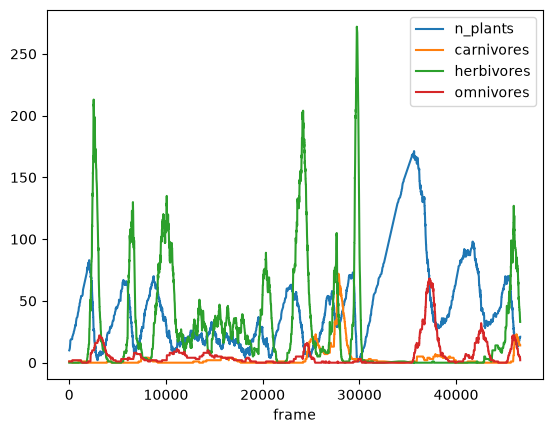

In [14]:
df["n_plants"].plot()
df["carnivores"].plot()
df["herbivores"].plot()
df["omnivores"].plot()
plt.legend()